Yuliia Chernysheva  
October 4, 2026  
CSC 2267

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Load Dataset and Initial Inspection
df_inequality_gdp = pd.read_csv("gini-vs-gdp-per-capita.csv")
df_inequality_gdp.head()

,Entity,Code,Year,Gini index,"GDP per capita, PPP (constant 2017 international $)",Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,Asia
1,Afghanistan,AFG,2002,NaN,1189.784668,NaN
2,Afghanistan,AFG,2003,NaN,1235.810063,NaN
3,Afghanistan,AFG,2004,NaN,1200.278013,NaN
4,Afghanistan,AFG,2005,NaN,1286.793659,NaN


In [3]:
# Rename Columns
names_dict = {'Gini index':'Gini_ind',
              'GDP per capita, PPP (constant 2017 international $)':'GDP_per_capita'}
df_selected = df_inequality_gdp.rename(columns=names_dict)
df_selected

,Entity,Code,Year,Gini_ind,GDP_per_capita,Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,Asia
1,Afghanistan,AFG,2002,NaN,1189.784668,NaN
2,Afghanistan,AFG,2003,NaN,1235.810063,NaN
3,Afghanistan,AFG,2004,NaN,1200.278013,NaN
4,Afghanistan,AFG,2005,NaN,1286.793659,NaN
...,...,...,...,...,...,...
8684,Zimbabwe,ZWE,2015,NaN,3198.982129,Africa
8685,Zimbabwe,ZWE,2016,NaN,3173.610829,NaN
8686,Zimbabwe,ZWE,2018,NaN,3341.665418,NaN
8687,Zimbabwe,ZWE,2020,NaN,2744.690758,NaN


In [4]:
# Clean Missing Values (Drop rows where both "Gini_ind", "GDP_per_capita" are NaN) 
df_selected = df_selected.dropna(subset=["Gini_ind", "GDP_per_capita"], how="all")
df_selected

,Entity,Code,Year,Gini_ind,GDP_per_capita,Continent
1,Afghanistan,AFG,2002,NaN,1189.784668,NaN
2,Afghanistan,AFG,2003,NaN,1235.810063,NaN
3,Afghanistan,AFG,2004,NaN,1200.278013,NaN
4,Afghanistan,AFG,2005,NaN,1286.793659,NaN
5,Afghanistan,AFG,2006,NaN,1315.789117,NaN
...,...,...,...,...,...,...
8683,Zimbabwe,ZWE,2014,NaN,3195.767970,NaN
8684,Zimbabwe,ZWE,2015,NaN,3198.982129,Africa
8685,Zimbabwe,ZWE,2016,NaN,3173.610829,NaN
8686,Zimbabwe,ZWE,2018,NaN,3341.665418,NaN


In [5]:
# Check Dataset Information & Memory Usage
df_selected.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8600 entries, 1 to 8687
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Entity          8600 non-null   object 
 1   Code            7033 non-null   object 
 2   Year            8600 non-null   int64  
 3   Gini_ind        4384 non-null   float64
 4   GDP_per_capita  7109 non-null   float64
 5   Continent       196 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 1.5 MB


In [6]:
# Extract Unique Entities List
entities_list = df_selected['Entity'].unique().tolist()
print(entities_list)

['Afghanistan', 'Africa Eastern and Southern', 'Africa Western and Central', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Arab World', 'Argentina', 'Argentina (Urban)', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Caribbean Small States', 'Cayman Islands', 'Central African Republic', 'Central Europe and the Baltics', 'Chad', 'Chile', 'China', 'China (Rural)', 'China (Urban)', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Curacao', 'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (IDA & IBRD)', 'East Asia & Pacific (excluding high income)',

In [7]:
# Filter Out Non-Country Entities (Regions, Income Groups, etc.)
not_countries = [
    "Africa Eastern and Southern","Africa Western and Central", "Arab World",
    "Argentina (Urban)", "Aruba", "Bermuda", "Caribbean Small States",
    "Cayman Islands", "Central Central Europe and the Baltics", "China (Rural)",
    "China (Urban)", "Curacao", "Early-demographic dividend", "East Asia & Pacific",
    "East Asia & Pacific (IDA & IBRD)", "East Asia & Pacific (excluding high income)",
    "Euro area", "Europe & Central Asia", "Europe & Central Asia (IDA & IBRD)",
    "Europe & Central Asia (excluding high income)", "European Union",
    "Heavily indebted poor countries (HIPC)", "High income", "Hong Kong",
    "IBRD only", "IDA & IBRD total", "IDA blend", "IDA only", "IDA total",
    "India (Rural)", "India (Urban)", "Indonesia (Rural)", "Indonesia (Urban)",
    "Latin America & Caribbean", "Latin America & Caribbean (IDA & IBRD)",
    "Latin America & Caribbean (excluding high income)", "Late-demographic dividend",
    "Least developed countries: UN classification", "Low & middle income",
    "Lower middle income", "Macao", "Middle East & North Africa",
    "Middle East & North Africa (IDA & IBRD)","Middle East & North Africa (excluding high income)",
    "Middle income", "North America", "OECD members", "Other small states",
    "Pacific island small states", "Palestine", "Post-demographic dividend",
    "Pre-demographic dividend", "Puerto Rico", "Sint Maarten (Dutch part)",
    "Small states", "South Asia", "South Asia (IDA & IBRD)", "Sub-Saharan Africa",
    "Sub-Saharan Africa (IDA & IBRD)", "Sub-Saharan Africa (excluding high income)",
    "Suriname (Urban)", "Turks and Caicos Islands", "Upper middle income", "World"
]

df_selected_countries = df_selected[~df_selected.Entity.isin(not_countries)]
df_selected_countries.head()

,Entity,Code,Year,Gini_ind,GDP_per_capita,Continent
1,Afghanistan,AFG,2002,NaN,1189.784668,NaN
2,Afghanistan,AFG,2003,NaN,1235.810063,NaN
3,Afghanistan,AFG,2004,NaN,1200.278013,NaN
4,Afghanistan,AFG,2005,NaN,1286.793659,NaN
5,Afghanistan,AFG,2006,NaN,1315.789117,NaN


In [8]:
# Drop Unnecessary Columns: Year, Continent, Code if they exist
drop_columns = ['Code','Continent']

df_selected_countries = df_selected_countries.drop(
    columns=drop_columns,
    errors='ignore'
)
df_selected_countries.head()

,Entity,Year,Gini_ind,GDP_per_capita
1,Afghanistan,2002,NaN,1189.784668
2,Afghanistan,2003,NaN,1235.810063
3,Afghanistan,2004,NaN,1200.278013
4,Afghanistan,2005,NaN,1286.793659
5,Afghanistan,2006,NaN,1315.789117


In [9]:
# Sort the data by country and year to ensure the correct time-series order
df_sorted = df_selected_countries.sort_values(['Entity', 'Year'])

# Create a copy for filling in the blanks
df_filled = df_sorted.copy()
df_filled.head()

,Entity,Year,Gini_ind,GDP_per_capita
1,Afghanistan,2002,NaN,1189.784668
2,Afghanistan,2003,NaN,1235.810063
3,Afghanistan,2004,NaN,1200.278013
4,Afghanistan,2005,NaN,1286.793659
5,Afghanistan,2006,NaN,1315.789117


In [10]:
# Fill missing values with the last known value (ffill) 
# and the previous one (bfill) for each country separately
df_filled['Gini_ind'] = (
    df_filled.groupby('Entity')['Gini_ind'].ffill().bfill()
)
df_filled['GDP_per_capita'] = (
    df_filled.groupby('Entity')['GDP_per_capita'].ffill().bfill()
)
df_filled.head()

,Entity,Year,Gini_ind,GDP_per_capita
1,Afghanistan,2002,27.01034,1189.784668
2,Afghanistan,2003,27.01034,1235.810063
3,Afghanistan,2004,27.01034,1200.278013
4,Afghanistan,2005,27.01034,1286.793659
5,Afghanistan,2006,27.01034,1315.789117


In [11]:
# Get the count of missing values
missing_count = df_filled.isnull().sum()
print(missing_count)

Entity            0
Year              0
Gini_ind          0
GDP_per_capita    0
dtype: int64


In [12]:
selected_year = 2019

# Take a snapshot based strictly on the target year (2019).
df_2019 = df_filled[df_filled['Year'] == selected_year].copy()
df_2019

,Entity,Year,Gini_ind,GDP_per_capita
18,Afghanistan,2019,27.01034,2065.036235
108,Albania,2019,33.17109,13671.488422
139,Algeria,2019,27.61573,11510.557088
183,Angola,2019,51.27211,6670.331458
235,Antigua and Barbuda,2019,44.41862,21548.725008
...,...,...,...,...
8480,Vanuatu,2019,37.62623,3117.678832
8525,Vietnam,2019,35.71555,8041.178384
8603,Yemen,2019,36.70709,2190.181724
8626,Zambia,2019,57.13606,3470.448024


In [13]:
# Remove countries that still have NaNs (those that had no data at all)
df_sel_2019 = df_2019.dropna(subset=['Gini_ind', 'GDP_per_capita'], how='any')

# Check the result
print(f"Number of countries with complete data for 2019: {len(df_sel_2019)}\n")
df_sel_2019.head()

Number of countries with complete data for 2019: 189



,Entity,Year,Gini_ind,GDP_per_capita
18,Afghanistan,2019,27.01034,2065.036235
108,Albania,2019,33.17109,13671.488422
139,Algeria,2019,27.61573,11510.557088
183,Angola,2019,51.27211,6670.331458
235,Antigua and Barbuda,2019,44.41862,21548.725008


In [14]:
# Statistical Summary of Cleaned Data
df_sel_2019.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,189.0,2019.000000,0.000000,2019.000000,2019.000000,2019.000000,2019.00000,2019.000000
Gini_ind,189.0,38.249112,8.578614,20.186580,32.380690,37.054930,43.71005,63.026070
GDP_per_capita,189.0,20255.673200,20592.241228,751.664153,4388.800909,13070.125645,28753.51627,113940.237442


In [15]:
display(
    df_sel_2019[df_sel_2019.Entity.isin(['Gabon', 'United States'])].style.hide(axis='index')
)

Entity,Year,Gini_ind,GDP_per_capita
Gabon,2019,38.024370,14950.077078
United States,2019,41.407840,62630.873277


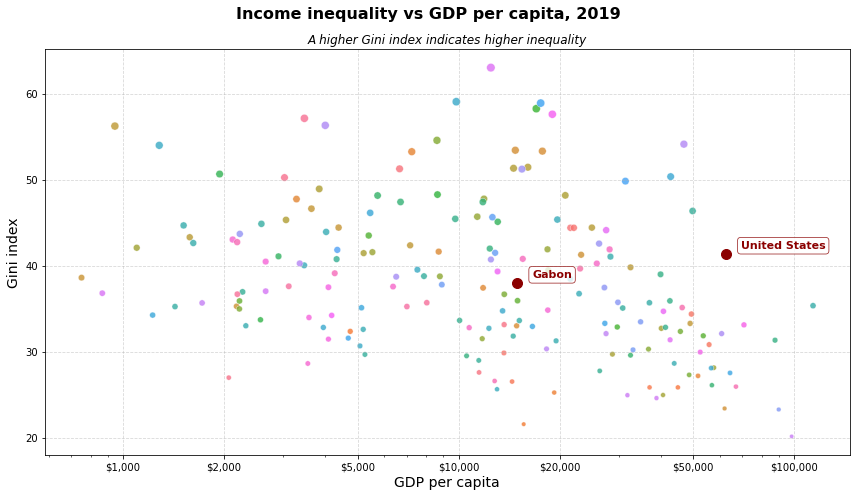

In [16]:
# Visualize Income Inequality vs GDP per Capita for 2019
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_sel_2019, 
    x='GDP_per_capita', 
    y='Gini_ind', 
    hue='Entity', 
    size='Gini_ind', 
    legend=False,
    alpha=0.8)

# Enable a logarithmic scale for the X-axis, as in the original
plt.xscale('log')

# Headings
plt.suptitle("Income inequality vs GDP per capita, 2019", 
             fontsize=16, fontweight='bold');
plt.title("A higher Gini index indicates higher inequality", 
          fontsize=12, style='italic')

plt.xlabel("GDP per capita", fontsize=14)
plt.ylabel("Gini index", fontsize=14)

# Format the X-axis with dollar signs and thousands separators
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Specify specific values on the X-axis so the tick marks look neat
ticks = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
ax.set_xticks(ticks)
ax.set_xticklabels([f'${t:,.0f}' for t in ticks])


# Highlight Gabon and the United States (as required in the PDF examples)
highlight_countries = ['Gabon', 'United States']
highlight_df = df_sel_2019[df_sel_2019['Entity'].isin(highlight_countries)]

for _, row in highlight_df.iterrows():
    # Draw a standout point for these countries
    plt.scatter(row['GDP_per_capita'], row['Gini_ind'], color='darkred', s=100, zorder=5)
    
    # Adding a text label next to the point
    plt.annotate(
        row['Entity'],
        xy=(row['GDP_per_capita'], row['Gini_ind']),
        xytext=(15, 5), textcoords='offset points',
        fontweight='bold', fontsize=11, color='darkred',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=0.8, alpha=0.8)
    )
    
plt.grid(True, which="major", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretation of Results

The scatter plot shows a weak negative relationship between GDP per capita and income inequality. In general, countries with higher GDP per capita tend to have somewhat lower Gini index values, although there is considerable variation among countries. For example, the United States has a high GDP per capita but also a relatively high level of income inequality. Gabon also illustrates that a higher GDP per capita does not necessarily mean that income is distributed equally. Overall, the graph suggests that economic development may be associated with lower inequality, but GDP per capita alone does not determine how equally income is distributed. Government policies and the distribution of wealth also play an important role.